# Logistic Regression

Logistic Regression is a **supervised machine learning algorithm** used mainly for **classification problems**.

Despite its name, Logistic Regression is a classification algorithm rather than a regression algorithm.

It predicts the probability that an observation belongs to a particular class.

For binary classification, the output is usually:

- 0 → Negative Class
- 1 → Positive Class

Examples:

- Spam or Not Spam
- Disease or No Disease
- Fraud or Not Fraud
- Pass or Fail
- Customer Churn or No Churn

The main idea of Logistic Regression is:

Input Features
        ↓
Linear Combination
        ↓
Sigmoid Function
        ↓
Probability
        ↓
Classification

## Learning Objectives

By the end of this notebook, we will understand:

- Why Logistic Regression is used for classification
- How the sigmoid function works
- How probabilities are converted into classes
- What a decision boundary is
- Why Logistic Regression uses log loss
- How Logistic Regression learns its parameters
- How multiple features are handled
- How to implement Logistic Regression from scratch
- How to use `LogisticRegression` from Scikit-learn
- How to evaluate a classification model
- How the decision threshold affects predictions

# Why Not Use Linear Regression for Classification?

Suppose we want to predict whether a student passes an exam.

We can represent the target as:

0 → Fail
1 → Pass

A linear regression model produces:

ŷ = b₀ + b₁x

The problem is that linear regression can produce predictions outside the range [0, 1].

For example:

- -0.4
- 0.3
- 0.8
- 1.4

These values cannot be interpreted as valid probabilities.

We therefore need a function that converts any real-valued number into a value between 0 and 1.

This is the purpose of the **Sigmoid Function**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

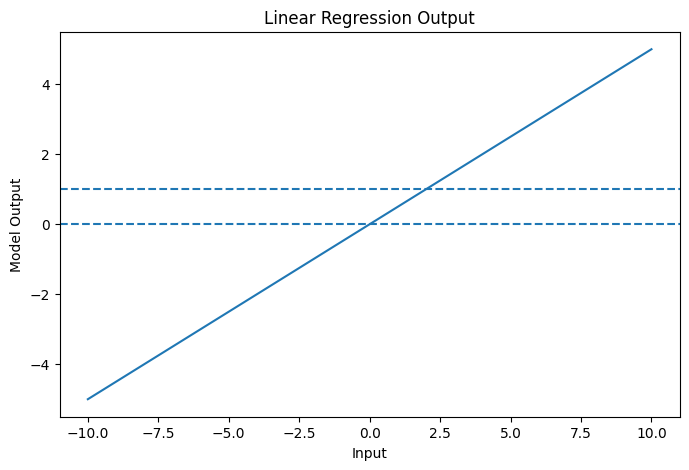

In [2]:
# Example linear regression output

x = np.linspace(-10, 10, 100)

y_linear = 0.5 * x

plt.figure(figsize=(8, 5))
plt.plot(x, y_linear)
plt.axhline(0, linestyle="--")
plt.axhline(1, linestyle="--")

plt.xlabel("Input")
plt.ylabel("Model Output")
plt.title("Linear Regression Output")

plt.show()

The linear model is not restricted to the interval [0, 1].

Therefore, it is not suitable for directly representing classification probabilities.

Logistic Regression solves this problem using the sigmoid function.

# What is Logistic Regression?

```text
Logistic Regression first calculates a linear combination of the input features:

z = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

The value `z` can be any real number.

This value is then passed through the sigmoid function.

The sigmoid function converts `z` into a probability between 0 and 1.

Therefore:

Features
   ↓
Linear Combination
   ↓
   z
   ↓
Sigmoid Function
   ↓
Probability
   ↓
Class

# Logistic Regression Equation

```text

For a single feature:

z = b₀ + b₁x

For multiple features:

z = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

The predicted probability is:

P(y = 1 | X) = σ(z)

where:

- `b₀` = intercept
- `b₁, b₂, ..., bₙ` = model coefficients
- `x₁, x₂, ..., xₙ` = input features
- `σ` = sigmoid function

# Sigmoid Function

```text
The sigmoid function is:

σ(z) = 1 / (1 + e⁻ᶻ)

It converts any real-valued number into a value between 0 and 1.

Important properties:

- If z → -∞, σ(z) → 0
- If z = 0, σ(z) = 0.5
- If z → +∞, σ(z) → 1

Therefore, the sigmoid function is useful for converting a model score into a probability.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

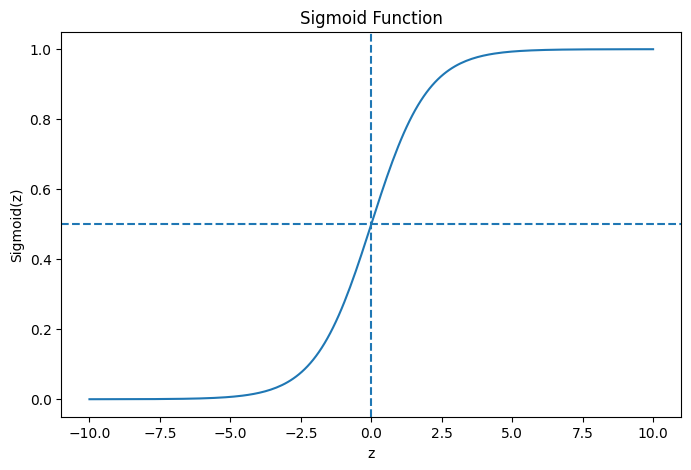

In [4]:
z = np.linspace(-10, 10, 200)

probability = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, probability)

plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")

plt.show()

In [5]:
values = np.array([-5, -2, 0, 2, 5])

for value in values:
    print(f"z = {value:>2}  →  sigmoid(z) = {sigmoid(value):.4f}")

z = -5  →  sigmoid(z) = 0.0067
z = -2  →  sigmoid(z) = 0.1192
z =  0  →  sigmoid(z) = 0.5000
z =  2  →  sigmoid(z) = 0.8808
z =  5  →  sigmoid(z) = 0.9933


### Interpretation
```text
For example:

z = -5 → probability ≈ 0.0067
z =  0 → probability = 0.5000
z =  5 → probability ≈ 0.9933

The sigmoid function therefore transforms the model's raw score into a probability.

# Probability and Classification

```text
Logistic Regression produces a probability.

For example:

P(y = 1) = 0.82

This means the model estimates an 82% probability that the observation belongs to class 1.

To convert the probability into a class, we normally use a threshold.

The common threshold is:

threshold = 0.5

Decision rule:

If P(y = 1) >= 0.5
    → predict 1

If P(y = 1) < 0.5
    → predict 0

In [6]:
probabilities = np.array([0.12, 0.35, 0.49, 0.51, 0.72, 0.91])

predictions = (probabilities >= 0.5).astype(int)

print("Probabilities:", probabilities)
print("Predictions:  ", predictions)

Probabilities: [0.12 0.35 0.49 0.51 0.72 0.91]
Predictions:   [0 0 0 1 1 1]


# Decision Boundary

```text
The decision boundary separates the different classes.

With a threshold of 0.5:

P(y = 1) = 0.5

For the sigmoid function:

σ(z) = 0.5

This happens when:

z = 0

Therefore:

b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ = 0

defines the decision boundary.

For two features, the boundary is a line.

For more features, it becomes a hyperplane.

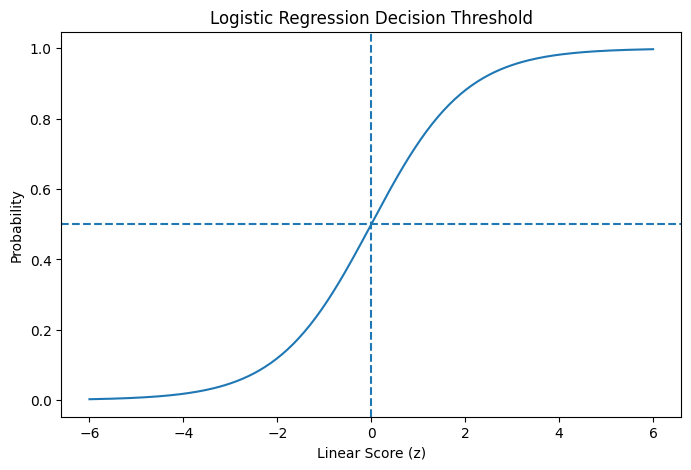

In [7]:
# Simple example of probabilities and classification

x = np.linspace(-6, 6, 200)
p = sigmoid(x)

plt.figure(figsize=(8, 5))
plt.plot(x, p)

plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Linear Score (z)")
plt.ylabel("Probability")
plt.title("Logistic Regression Decision Threshold")

plt.show()

# Loss Function: Log Loss

```text
Logistic Regression cannot use the ordinary Mean Squared Error as its standard loss function.

Instead, it uses **Log Loss**, also called:

- Binary Cross-Entropy
- Binary Log Loss

For one observation:

Loss = -[y log(p) + (1-y) log(1-p)]

where:

- `y` = actual class
- `p` = predicted probability

If y = 1:

Loss = -log(p)

If y = 0:

Loss = -log(1-p)

The loss is small when the model is confident and correct.

The loss becomes very large when the model is confident and wrong.

In [8]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -(y_true * np.log(y_pred) +
             (1 - y_true) * np.log(1 - y_pred))

    return loss

In [9]:
# Actual class = 1

y_true = 1

probabilities = np.array([0.01, 0.2, 0.5, 0.8, 0.99])

losses = [
    binary_cross_entropy(y_true, p)
    for p in probabilities
]

for p, loss in zip(probabilities, losses):
    print(f"Probability = {p:.2f}, Loss = {loss:.4f}")

Probability = 0.01, Loss = 4.6052
Probability = 0.20, Loss = 1.6094
Probability = 0.50, Loss = 0.6931
Probability = 0.80, Loss = 0.2231
Probability = 0.99, Loss = 0.0101


### Interpretation

When the true class is 1:

- Predicting 0.99 → very small loss
- Predicting 0.80 → small loss
- Predicting 0.50 → moderate loss
- Predicting 0.01 → very large loss

This strongly penalizes confident incorrect predictions.

# Cost Function
```text

The loss function measures the error for one training example.

For the entire dataset, we calculate the average loss.

The Logistic Regression cost function is:

J(β) = -(1/m) Σ [yᵢ log(pᵢ) + (1-yᵢ) log(1-pᵢ)]

where:

- `m` = number of training examples
- `yᵢ` = actual value
- `pᵢ` = predicted probability

Training Logistic Regression means finding model parameters that minimize this cost function.

# How Logistic Regression Learns

```text
The model starts with initial parameter values.

Then it repeatedly:

1. Calculates the linear score

   z = Xβ

2. Calculates probabilities using sigmoid

   p = σ(z)

3. Calculates the cost

4. Calculates gradients

5. Updates the parameters

6. Repeats the process

The parameter update is based on Gradient Descent:

β := β - α ∇J(β)

where:

- `β` = model parameters
- `α` = learning rate
- `∇J(β)` = gradient of the cost function

# Multiple Logistic Regression

```text
Logistic Regression can use multiple input features.

For example, suppose we want to predict whether a student passes an exam using:

- Hours Studied
- Attendance
- Previous Score

The linear part becomes:

z = b₀
    + b₁(Hours Studied)
    + b₂(Attendance)
    + b₃(Previous Score)

The probability is then:

P(y = 1 | X) = σ(z)

Therefore, Logistic Regression naturally supports multiple features.

For `n` features:

z = b₀ + Σ bⱼxⱼ

and:

P(y = 1 | X) = σ(z)

## Vector Form

The same equation can be written compactly as:

z = Xβ

and:

p = σ(Xβ)

where:

- `X` = feature matrix
- `β` = parameter vector
- `p` = predicted probability vector

This vectorized form is what we will use when implementing Logistic Regression from scratch.

# Logistic Regression from Scratch

We will implement a simple binary Logistic Regression model using:

- NumPy
- Sigmoid function
- Binary Cross-Entropy
- Gradient Descent

We will first create a small dataset.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [11]:
# Create a simple binary classification dataset

X_class_0 = np.random.normal(
    loc=[2, 2],
    scale=1,
    size=(50, 2)
)

X_class_1 = np.random.normal(
    loc=[6, 6],
    scale=1,
    size=(50, 2)
)

X = np.vstack([X_class_0, X_class_1])

y = np.hstack([
    np.zeros(50),
    np.ones(50)
])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 2)
y shape: (100,)


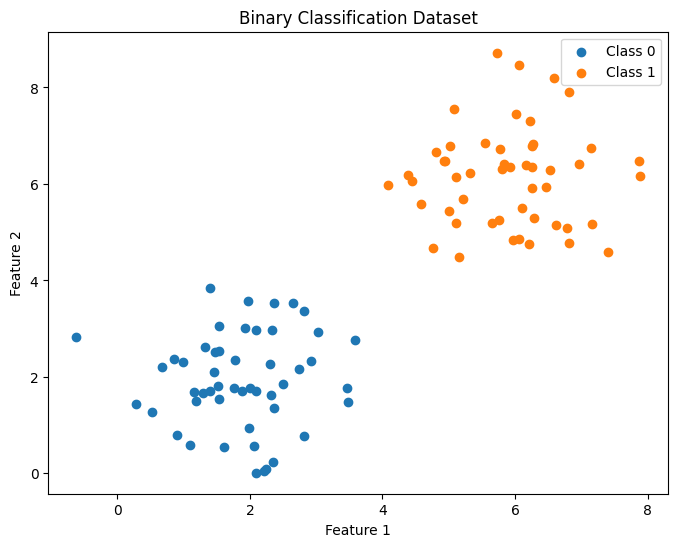

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.legend()

plt.show()

## Adding the Intercept

Our equation contains an intercept:

z = b₀ + b₁x₁ + b₂x₂

To perform this efficiently using matrix multiplication, we add a column of ones to `X`.

Therefore:

X_augmented = [1, x₁, x₂]

and:

β = [b₀, b₁, b₂]

Then:

z = X_augmented β

In [13]:
X_augmented = np.c_[
    np.ones(X.shape[0]),
    X
]

print(X_augmented.shape)
print(X_augmented[:5])

(100, 3)
[[1.         2.49671415 1.8617357 ]
 [1.         2.64768854 3.52302986]
 [1.         1.76584663 1.76586304]
 [1.         3.57921282 2.76743473]
 [1.         1.53052561 2.54256004]]


## Define Sigmoid

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## Define Cost Function

In [15]:
def compute_cost(X, y, weights):
    z = X @ weights
    probabilities = sigmoid(z)

    epsilon = 1e-15
    probabilities = np.clip(
        probabilities,
        epsilon,
        1 - epsilon
    )

    cost = -np.mean(
        y * np.log(probabilities) +
        (1 - y) * np.log(1 - probabilities)
    )

    return cost

## Gradient Descent
```text

For Logistic Regression, the gradient of the cost function is:

∇J(β) = (1/m) Xᵀ(p - y)

The parameters are updated using:

β := β - α ∇J(β)

In [16]:
def train_logistic_regression(X, y, learning_rate=0.01, epochs=1000):
    
    n_samples, n_features = X.shape
    
    weights = np.zeros(n_features)
    
    cost_history = []

    for epoch in range(epochs):
        
        # Linear combination
        z = X @ weights
        
        # Predicted probabilities
        probabilities = sigmoid(z)
        
        # Gradient
        gradient = (1 / n_samples) * X.T @ (
            probabilities - y
        )
        
        # Update weights
        weights -= learning_rate * gradient
        
        # Store cost
        cost = compute_cost(X, y, weights)
        cost_history.append(cost)

    return weights, cost_history

## Train the Model

In [17]:
weights, cost_history = train_logistic_regression(
    X_augmented,
    y,
    learning_rate=0.1,
    epochs=1000
)

print("Learned weights:")
print(weights)

Learned weights:
[-5.7882028   0.86244936  0.71078197]


## Plot Cost

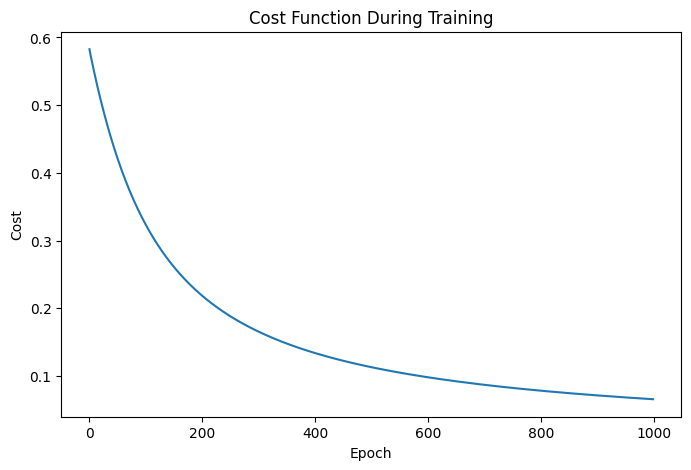

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Cost Function During Training")

plt.show()

The decreasing cost shows that the optimization process is learning parameters that improve the model's predictions.

## Predictions from Scratch

In [19]:
def predict_probability(X, weights):
    return sigmoid(X @ weights)

In [20]:
def predict_class(X, weights, threshold=0.5):
    probabilities = predict_probability(X, weights)
    
    return (probabilities >= threshold).astype(int)

In [21]:
probabilities = predict_probability(
    X_augmented,
    weights
)

predictions = predict_class(
    X_augmented,
    weights
)

print("First 10 probabilities:")
print(probabilities[:10])

print("\nFirst 10 predictions:")
print(predictions[:10])

First 10 probabilities:
[0.09016474 0.26882359 0.04697141 0.32425834 0.06531449 0.03316776
 0.02203191 0.01067563 0.03585031 0.01178928]

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


## Accuracy from Scratch

In [22]:
accuracy = np.mean(predictions == y)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


# Logistic Regression using Scikit-learn

In real machine learning projects, we normally use a library implementation rather than manually implementing the optimization algorithm.

Scikit-learn provides:

`LogisticRegression`

We will now train Logistic Regression using Scikit-learn.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 80
Testing samples: 20


In [25]:
model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predicted classes:")
print(y_pred)

print("\nPredicted probabilities:")
print(y_probability)

Predicted classes:
[1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1.]

Predicted probabilities:
[9.96347173e-01 9.92573216e-01 9.65611995e-01 9.80227278e-01
 1.86532455e-04 1.25832100e-03 1.46202232e-02 9.98124840e-01
 3.97117521e-04 2.11180491e-04 7.11701650e-04 9.78721809e-01
 3.11611141e-03 3.19456988e-03 2.29292861e-02 9.97560430e-01
 9.92666529e-01 8.86050975e-04 9.99862315e-01 9.83744419e-01]


# Model Coefficients

The trained model learns:

- Intercept
- Feature coefficients

For our model:

z = b₀ + b₁x₁ + b₂x₂

We can inspect these learned parameters.

In [27]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
print(model.coef_)

Intercept:
[-10.9163339]

Coefficients:
[[1.37205901 1.35784186]]


A positive coefficient increases the linear score as the corresponding feature increases.

A negative coefficient decreases the linear score.

Because the score is passed through the sigmoid function, the coefficients affect the predicted probability of class 1.

# Model Evaluation

Accuracy alone is not always enough for classification problems.

We will examine:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-Score
- ROC Curve
- AUC

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


# Confusion Matrix

A confusion matrix contains four outcomes:

| Actual | Predicted | Meaning |
|---|---|---|
| 0 | 0 | True Negative |
| 0 | 1 | False Positive |
| 1 | 0 | False Negative |
| 1 | 1 | True Positive |

These four values help us understand the types of errors made by the classifier.

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[10  0]
 [ 0 10]]


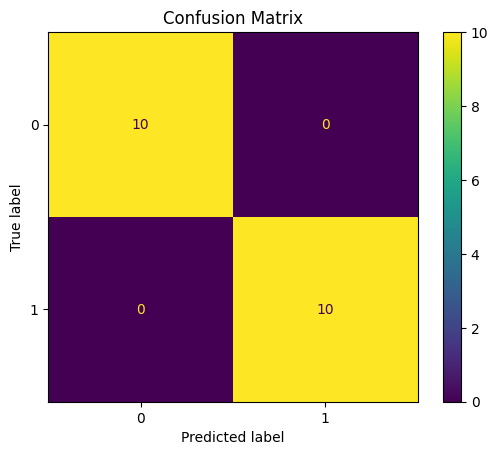

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Confusion Matrix")

plt.show()

## Precision, Recall and F1-Score

In [31]:
from sklearn.metrics import (
    classification_report
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        10
         1.0       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## Precision

Precision answers:

> Of all observations predicted as positive, how many were actually positive?

Precision = TP / (TP + FP)

---

## Recall

Recall answers:

> Of all actual positive observations, how many did the model correctly identify?

Recall = TP / (TP + FN)

---

## F1-Score

F1-score is the harmonic mean of precision and recall.

F1 = 2 × (Precision × Recall) / (Precision + Recall)

F1-score is useful when we want a balance between precision and recall.

# ROC Curve and AUC

The ROC curve evaluates a classifier across different probability thresholds.

It plots:

True Positive Rate vs False Positive Rate

where:

TPR = TP / (TP + FN)

and:

FPR = FP / (FP + TN)

AUC means:

Area Under the ROC Curve

A larger AUC generally indicates better ability to distinguish between the two classes.

In [32]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc = roc_auc_score(
    y_test,
    y_probability
)

print(f"AUC: {auc:.4f}")

AUC: 1.0000


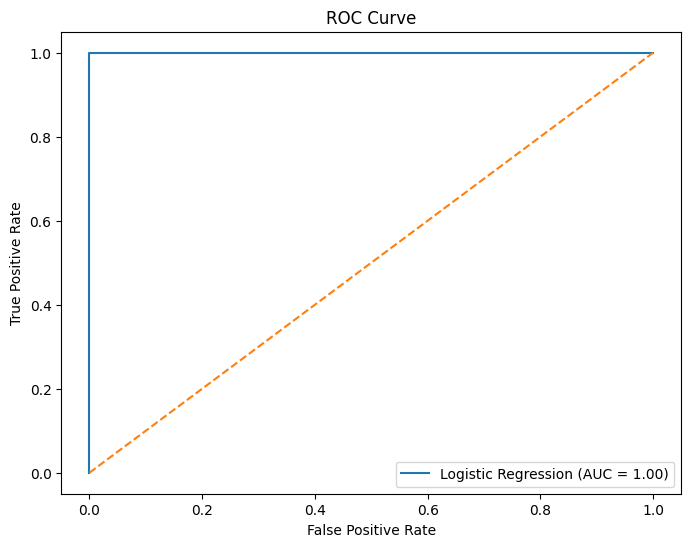

In [33]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Effect of Decision Threshold

Logistic Regression produces probabilities.

The classification threshold determines how those probabilities are converted into classes.

For example:

Threshold = 0.5

If:

P(y = 1) >= 0.5 → Class 1

Otherwise:

P(y = 1) < 0.5 → Class 0

But we can choose other thresholds such as:

- 0.3
- 0.4
- 0.6
- 0.7

Changing the threshold changes the number of positive and negative predictions.

A lower threshold generally makes the model predict more positive cases.

A higher threshold generally makes the model more conservative about predicting positive cases.

In [34]:
thresholds_to_test = [0.3, 0.5, 0.7]

for threshold in thresholds_to_test:
    
    predictions_threshold = (
        y_probability >= threshold
    ).astype(int)
    
    accuracy = accuracy_score(
        y_test,
        predictions_threshold
    )
    
    print(
        f"Threshold = {threshold:.1f} "
        f"| Accuracy = {accuracy:.2f}"
    )

Threshold = 0.3 | Accuracy = 1.00
Threshold = 0.5 | Accuracy = 1.00
Threshold = 0.7 | Accuracy = 1.00


# Practical Example: Breast Cancer Classification

We will use the Breast Cancer dataset available in Scikit-learn.

The goal is to predict whether a tumor is:

- Malignant
- Benign

This is a binary classification problem, making it suitable for Logistic Regression.

In [35]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569,)


In [36]:
print("Feature names:")
print(data.feature_names)

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [37]:
print("Target names:")
print(data.target_names)

Target names:
['malignant' 'benign']


## Train-Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (455, 30)
X_test:  (114, 30)
y_train: (455,)
y_test:  (114,)


# Feature Scaling

Logistic Regression can benefit from feature scaling, especially when features have very different numerical ranges.

We will use StandardScaler.

Standardization transforms a feature approximately as:

z = (x - μ) / σ

where:

- `μ` = feature mean
- `σ` = feature standard deviation

Important:

The scaler is fitted only on the training data.

The same transformation is then applied to the test data.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Train Logistic Regression

In [40]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predictions

In [41]:
y_pred = logistic_model.predict(
    X_test_scaled
)

y_probability = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

## Evaluate the Practical Model

In [42]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9825


In [43]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Confusion Matrix

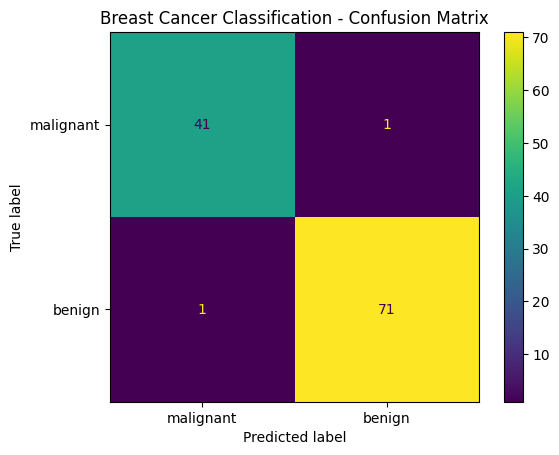

In [44]:
cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
).plot()

plt.title("Breast Cancer Classification - Confusion Matrix")

plt.show()

## ROC-AUC

In [45]:
auc = roc_auc_score(
    y_test,
    y_probability
)

print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.9954


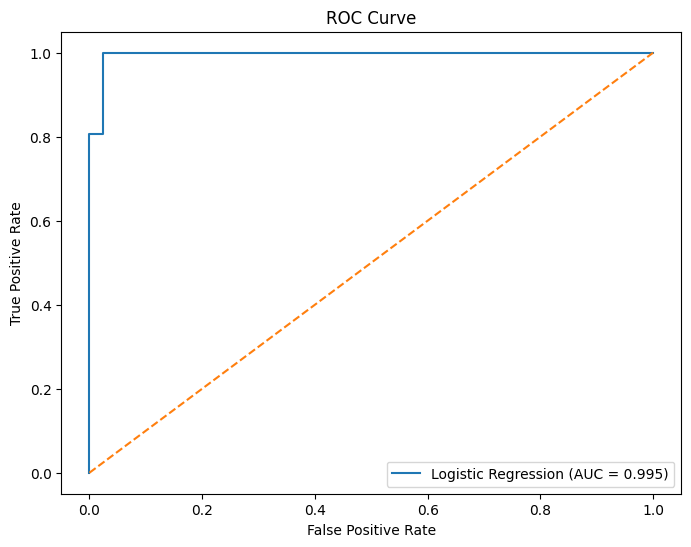

In [46]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

# Advantages of Logistic Regression

- Simple and easy to understand
- Fast to train
- Produces probability estimates
- Works well for many binary classification problems
- Coefficients can provide useful interpretation
- Works well with high-dimensional data
- Provides a strong baseline classification model

---

# Limitations of Logistic Regression

- Assumes a linear relationship between features and the log-odds
- May struggle with highly nonlinear decision boundaries
- Sensitive to extreme outliers
- Feature scaling can be important
- More complex problems may require nonlinear models
- Multicollinearity can make coefficient interpretation unstable

# Logistic Regression vs Linear Regression

| Property | Linear Regression | Logistic Regression |
|---|---|---|
| Main task | Regression | Classification |
| Output | Continuous value | Probability |
| Typical target | Numerical | Categorical |
| Main function | Linear function | Sigmoid function |
| Common loss | MSE | Log Loss |
| Example | House price | Spam detection |
| Output range | Any real value | 0 to 1 probability |

# Summary

In this notebook, we learned:

1. Logistic Regression is primarily a classification algorithm.

2. It first calculates a linear combination:

   z = b₀ + b₁x₁ + ... + bₙxₙ

3. The sigmoid function converts this value into a probability:

   σ(z) = 1 / (1 + e⁻ᶻ)

4. A decision threshold converts probability into a class.

5. Logistic Regression uses Log Loss / Binary Cross-Entropy as its loss function.

6. The model learns its parameters by minimizing the cost function.

7. Logistic Regression can work with multiple features.

8. We implemented Logistic Regression from scratch using NumPy.

9. We trained Logistic Regression using Scikit-learn.

10. We evaluated the model using:

    - Accuracy
    - Confusion Matrix
    - Precision
    - Recall
    - F1-Score
    - ROC Curve
    - AUC

11. The decision threshold can be changed depending on the problem.

Logistic Regression is one of the most important algorithms to understand before moving to more advanced classification algorithms.

# Key Formula Sheet

### Linear Score

z = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

### Sigmoid Function

σ(z) = 1 / (1 + e⁻ᶻ)

### Probability

P(y = 1 | X) = σ(Xβ)

### Binary Cross-Entropy

L = -[y log(p) + (1-y) log(1-p)]

### Cost Function

J(β) = -(1/m) Σ [yᵢ log(pᵢ) + (1-yᵢ) log(1-pᵢ)]

### Gradient

∇J(β) = (1/m) Xᵀ(p-y)

### Gradient Descent

β := β - α∇J(β)

### Decision Rule

If P(y=1|X) ≥ threshold → Class 1

Otherwise → Class 0